# Week 1 — The Transformer as a Residual Stream

**Goal:** Load GPT-2 Small in TransformerLens, run a forward pass, inspect the residual stream at every layer, and build intuition for what the tensors represent.

**Plan reference:** Phase 0, Week 1  
**Date:** 2026-03-21

---

### What we're trying to understand

The key insight from Elhage et al. (2021) is that transformers aren't just "stacked layers" — they are better understood as a **residual stream** that attention heads and MLP layers read from and write to independently. Each component's contribution can be analyzed in isolation.

By the end of this notebook you should be able to answer:
- What are the dimensions of the residual stream, and what does each represent?
- How does the norm of the residual stream change across layers?
- How do I access any internal activation by name?

## 1. Setup

In [1]:
import torch
import transformer_lens
from transformer_lens import HookedTransformer
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# Use MPS (Apple Silicon GPU) if available, otherwise CPU
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {device}")
print(f"TransformerLens version: {transformer_lens.__version__ if hasattr(transformer_lens, '__version__') else 'unknown'}")

Using device: mps
TransformerLens version: unknown


## 2. Load GPT-2 Small

GPT-2 Small has:
- **12 layers**
- **12 attention heads** per layer
- **768 dimensions** in the residual stream (d_model)
- **50,257 token vocabulary**

We use `HookedTransformer` — TransformerLens's wrapper that adds activation caching and hooking on top of the standard model.

In [2]:
model = HookedTransformer.from_pretrained("gpt2", device=device)

print(f"\nModel config:")
print(f"  Layers (n_layers):     {model.cfg.n_layers}")
print(f"  Attention heads:       {model.cfg.n_heads}")
print(f"  Residual stream (d_model): {model.cfg.d_model}")
print(f"  MLP hidden size (d_mlp):   {model.cfg.d_mlp}")
print(f"  Vocabulary size:       {model.cfg.d_vocab}")

`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model gpt2 into HookedTransformer

Model config:
  Layers (n_layers):     12
  Attention heads:       12
  Residual stream (d_model): 768
  MLP hidden size (d_mlp):   3072
  Vocabulary size:       50257


## 3. Run a Forward Pass and Cache All Activations

`run_with_cache()` runs the model and returns both the output logits and a `ActivationCache` object containing every intermediate activation, addressable by name.

The residual stream after each layer is stored as `resid_post.{layer}`.  
The shape is always `(batch, sequence_position, d_model)` — i.e. `(1, n_tokens, 768)`.

In [3]:
prompt = "The quick brown fox jumps over the lazy dog"
tokens = model.to_tokens(prompt)
token_strs = model.to_str_tokens(prompt)

print(f"Prompt:   '{prompt}'")
print(f"Tokens:   {tokens.shape}  →  {tokens[0].tolist()}")
print(f"As strings: {token_strs}")

# Run forward pass, caching all activations
logits, cache = model.run_with_cache(tokens)

print(f"\nLogits shape: {logits.shape}  (batch, seq_len, vocab_size)")
print(f"\nSample cache keys (first 10):")
for key in list(cache.keys())[:10]:
    print(f"  {key}: {cache[key].shape}")

Prompt:   'The quick brown fox jumps over the lazy dog'
Tokens:   torch.Size([1, 10])  →  [50256, 464, 2068, 7586, 21831, 18045, 625, 262, 16931, 3290]
As strings: ['<|endoftext|>', 'The', ' quick', ' brown', ' fox', ' jumps', ' over', ' the', ' lazy', ' dog']



Logits shape: torch.Size([1, 10, 50257])  (batch, seq_len, vocab_size)

Sample cache keys (first 10):
  hook_embed: torch.Size([1, 10, 768])
  hook_pos_embed: torch.Size([1, 10, 768])
  blocks.0.hook_resid_pre: torch.Size([1, 10, 768])
  blocks.0.ln1.hook_scale: torch.Size([1, 10, 1])
  blocks.0.ln1.hook_normalized: torch.Size([1, 10, 768])
  blocks.0.attn.hook_q: torch.Size([1, 10, 12, 64])
  blocks.0.attn.hook_k: torch.Size([1, 10, 12, 64])
  blocks.0.attn.hook_v: torch.Size([1, 10, 12, 64])
  blocks.0.attn.hook_attn_scores: torch.Size([1, 12, 10, 10])
  blocks.0.attn.hook_pattern: torch.Size([1, 12, 10, 10])


## 4. Inspect Residual Stream Shapes and Norms

For each layer, extract the residual stream and compute its L2 norm across the d_model dimension. This tells us how much "information" (loosely) is being carried at each position after each layer.

**Key question to hold in mind:** Does the norm grow, shrink, or stay flat across layers? What might that tell us about where the model is doing most of its work?

In [4]:
n_layers = model.cfg.n_layers

# Collect residual stream at each layer for each token position
# Shape per layer: (seq_len, d_model)
resid_norms = []  # shape: (n_layers, seq_len)

for layer in range(n_layers):
    resid = cache["resid_post", layer][0]  # remove batch dim → (seq_len, d_model)
    norms = resid.norm(dim=-1).cpu().float().numpy()  # (seq_len,)
    resid_norms.append(norms)

resid_norms = np.array(resid_norms)  # (n_layers, seq_len)

print(f"Residual stream shape per layer: (seq_len={resid_norms.shape[1]}, d_model={model.cfg.d_model})")
print(f"\nNorm at layer 0 (after first attention+MLP): {resid_norms[0]}")
print(f"Norm at layer 11 (final layer):              {resid_norms[-1]}")

Residual stream shape per layer: (seq_len=10, d_model=768)

Norm at layer 0 (after first attention+MLP): [165.21477   57.043633  63.844215  66.81207   68.65529   58.4225
  56.655457  57.333054  67.867035  60.507164]
Norm at layer 11 (final layer):              [417.39368 478.13535 373.08746 345.2292  393.97647 450.86606 475.09067
 481.92285 506.86893 430.25958]


## 5. Plot: Residual Stream Norm Across Layers

Two views:
1. **Heatmap** — norm at every (layer, token position), so we can see which tokens carry more signal
2. **Line plot** — mean norm across positions per layer, so we can see the overall trajectory

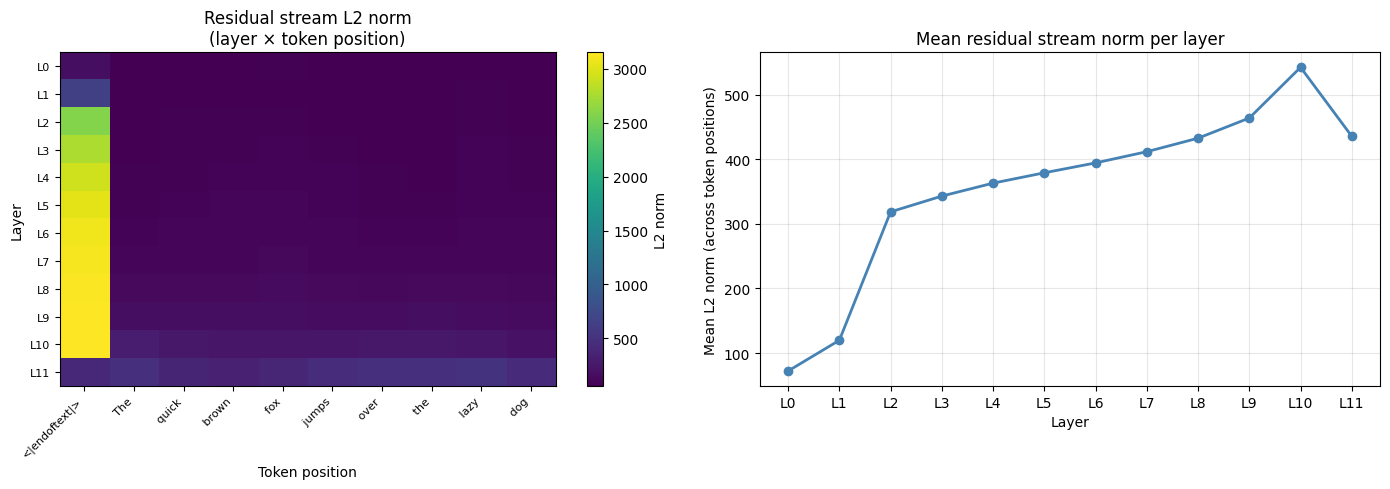

Saved to results/w01-residual-stream-norms.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Heatmap ---
ax = axes[0]
im = ax.imshow(resid_norms, aspect="auto", cmap="viridis", origin="upper")
ax.set_xlabel("Token position")
ax.set_ylabel("Layer")
ax.set_title("Residual stream L2 norm\n(layer × token position)")
ax.set_xticks(range(len(token_strs)))
ax.set_xticklabels(token_strs, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(n_layers))
ax.set_yticklabels([f"L{i}" for i in range(n_layers)], fontsize=8)
plt.colorbar(im, ax=ax, label="L2 norm")

# --- Mean norm per layer ---
ax2 = axes[1]
mean_norms = resid_norms.mean(axis=1)
ax2.plot(range(n_layers), mean_norms, marker="o", linewidth=2, color="steelblue")
ax2.set_xlabel("Layer")
ax2.set_ylabel("Mean L2 norm (across token positions)")
ax2.set_title("Mean residual stream norm per layer")
ax2.set_xticks(range(n_layers))
ax2.set_xticklabels([f"L{i}" for i in range(n_layers)])
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../results/w01-residual-stream-norms.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to results/w01-residual-stream-norms.png")

## 6. Explore the Full Cache

The cache contains every intermediate activation in the model. Let's see what's available and understand the naming convention — this is how we'll access specific components in later experiments.

In [6]:
all_keys = list(cache.keys())
print(f"Total cached activations: {len(all_keys)}\n")

# Group by type
from collections import defaultdict
groups = defaultdict(list)
for k in all_keys:
    prefix = k.split(".")[0]
    groups[prefix].append(k)

for prefix, keys in sorted(groups.items()):
    print(f"{prefix:20s}  {len(keys):3d} entries   example shape: {cache[keys[0]].shape}")

print("\n--- Key naming pattern ---")
print("  embed              → token embeddings")
print("  pos_embed          → positional embeddings")
print("  resid_pre.{L}      → residual stream BEFORE layer L")
print("  resid_post.{L}     → residual stream AFTER layer L")
print("  attn_out.{L}       → attention output at layer L")
print("  mlp_out.{L}        → MLP output at layer L")
print("  attn.{L}.hook_z    → attention head output vectors (pre-projection)")
print("  attn.{L}.hook_attn_scores → raw attention scores (pre-softmax)")

Total cached activations: 208

blocks                204 entries   example shape: torch.Size([1, 10, 768])
hook_embed              1 entries   example shape: torch.Size([1, 10, 768])
hook_pos_embed          1 entries   example shape: torch.Size([1, 10, 768])
ln_final                2 entries   example shape: torch.Size([1, 10, 1])

--- Key naming pattern ---
  embed              → token embeddings
  pos_embed          → positional embeddings
  resid_pre.{L}      → residual stream BEFORE layer L
  resid_post.{L}     → residual stream AFTER layer L
  attn_out.{L}       → attention output at layer L
  mlp_out.{L}        → MLP output at layer L
  attn.{L}.hook_z    → attention head output vectors (pre-projection)
  attn.{L}.hook_attn_scores → raw attention scores (pre-softmax)


## 7. Decompose Residual Stream: Attention vs MLP Contributions

At each layer, the residual stream is updated by two components:
```
resid_post[L] = resid_pre[L] + attn_out[L] + mlp_out[L]
```

Let's measure how much each component contributes (by L2 norm) at each layer. This tells us whether attention heads or MLPs are doing more of the work — and whether that balance shifts across layers.

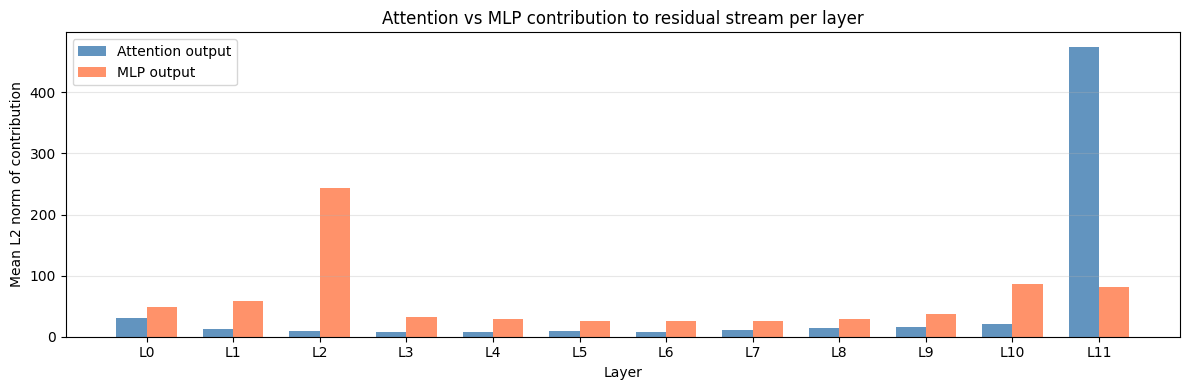


Layer-by-layer summary:
 Layer   Attn norm    MLP norm    Dominant
  L 0        30.20       49.48         MLP
  L 1        12.88       58.52         MLP
  L 2         9.32      243.93         MLP
  L 3         8.00       32.92         MLP
  L 4         7.21       28.49         MLP
  L 5         8.92       25.50         MLP
  L 6         7.76       25.55         MLP
  L 7        10.69       26.18         MLP
  L 8        13.50       28.51         MLP
  L 9        15.76       36.71         MLP
  L10        20.26       85.67         MLP
  L11       474.60       81.89        Attn


In [7]:
attn_norms = []
mlp_norms  = []

for layer in range(n_layers):
    # Mean L2 norm across token positions for each component
    attn = cache["attn_out", layer][0].norm(dim=-1).mean().item()
    mlp  = cache["mlp_out", layer][0].norm(dim=-1).mean().item()
    attn_norms.append(attn)
    mlp_norms.append(mlp)

layers = list(range(n_layers))
x = np.arange(n_layers)
width = 0.35

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x - width/2, attn_norms, width, label="Attention output", color="steelblue", alpha=0.85)
ax.bar(x + width/2, mlp_norms,  width, label="MLP output",       color="coral",     alpha=0.85)
ax.set_xlabel("Layer")
ax.set_ylabel("Mean L2 norm of contribution")
ax.set_title("Attention vs MLP contribution to residual stream per layer")
ax.set_xticks(x)
ax.set_xticklabels([f"L{i}" for i in layers])
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../results/w01-attn-vs-mlp-contributions.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nLayer-by-layer summary:")
print(f"{'Layer':>6}  {'Attn norm':>10}  {'MLP norm':>10}  {'Dominant':>10}")
for i in range(n_layers):
    dominant = "Attn" if attn_norms[i] > mlp_norms[i] else "MLP"
    print(f"  L{i:2d}   {attn_norms[i]:10.2f}  {mlp_norms[i]:10.2f}  {dominant:>10}")

## 8. Verify: What Does the Model Predict?

Before we go deeper, let's confirm the model is working correctly by checking its next-token predictions. For each position in the prompt, we'll find the top-3 predicted next tokens.

This also builds intuition for what the residual stream is "for" — by the final layer, it contains everything needed to produce these predictions.

In [8]:
probs = logits[0].softmax(dim=-1)  # (seq_len, vocab_size)

print(f"{'Position':>8}  {'Input token':>14}  Top-3 predictions")
print("-" * 65)
for pos, tok_str in enumerate(token_strs):
    top3 = probs[pos].topk(3)
    top3_strs = [repr(model.to_single_str_token(idx.item())) for idx in top3.indices]
    top3_probs = [f"{p:.2%}" for p in top3.values.tolist()]
    preds = "  |  ".join(f"{t} ({p})" for t, p in zip(top3_strs, top3_probs))
    print(f"  [{pos:2d}]  {repr(tok_str):>14}  →  {preds}")

Position     Input token  Top-3 predictions
-----------------------------------------------------------------


  [ 0]  '<|endoftext|>'  →  '\n' (6.23%)  |  'The' (3.77%)  |  '"' (2.41%)
  [ 1]           'The'  →  ' first' (1.00%)  |  ' U' (0.87%)  |  ' following' (0.81%)
  [ 2]        ' quick'  →  ' and' (11.46%)  |  ' answer' (10.22%)  |  '-' (7.19%)
  [ 3]        ' brown'  →  'ie' (16.75%)  |  'ies' (5.62%)  |  ' rice' (2.73%)
  [ 4]          ' fox'  →  ' is' (8.95%)  |  'es' (7.77%)  |  ' was' (4.43%)
  [ 5]        ' jumps'  →  ' out' (13.70%)  |  ' up' (12.32%)  |  ' over' (7.63%)
  [ 6]         ' over'  →  ' the' (34.06%)  |  ' a' (26.71%)  |  ' his' (2.57%)
  [ 7]          ' the'  →  ' fence' (5.94%)  |  ' wall' (2.11%)  |  ' edge' (1.98%)
  [ 8]         ' lazy'  →  ',' (4.22%)  |  ' fox' (3.68%)  |  ' dog' (3.05%)
  [ 9]          ' dog'  →  ' and' (23.94%)  |  ',' (14.54%)  |  '.' (11.02%)


## 9. Reflection

*Fill this in after running the notebook. Use it as the basis for the lab notebook entry.*

**Questions to answer in your own words:**

1. What are the three dimensions of the residual stream tensor, and what does each represent?
2. Looking at the norm heatmap — which tokens seem to accumulate the most signal? Does that make intuitive sense?
3. Does the mean norm grow or shrink across layers? What might that tell us?
4. Which layers are attention-dominated vs MLP-dominated? Does the pattern surprise you?
5. Looking at the next-token predictions — do any of them seem surprisingly good or bad?

**Anything unexpected or worth investigating further:**

*(write your observations here)*